In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

data_path = Path("../data/processed/qualified_hitters_statcast_2021_2025_batted_ball.csv")
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns)
display(df.head())

player_counts = df.groupby("Name").size().reset_index(name="num_pitches")
print(f"Total unique players: {player_counts['Name'].nunique()}")
player_counts.sort_values("num_pitches", ascending=False)

# metrics: woba, xwoba, exit_velocity, launch_angle 

Dataset shape: (767599, 64)

Column names:
Index(['Season', 'game_date', 'game_pk', 'batter', 'pitcher', 'player_name',
       'Name', 'IDfg', 'mlbam_id', 'home_team', 'away_team', 'inning',
       'inning_topbot', 'at_bat_number', 'pitch_number', 'balls', 'strikes',
       'stand', 'p_throws', 'pitch_type', 'pitch_name', 'description',
       'events', 'zone', 'plate_x', 'plate_z', 'sz_top', 'sz_bot',
       'launch_speed', 'launch_angle', 'hit_distance_sc',
       'estimated_ba_using_speedangle', 'estimated_woba_using_speedangle',
       'woba_value', 'babip_value', 'iso_value', 'hc_x', 'hc_y', 'bb_type',
       'on_1b', 'on_2b', 'on_3b', 'season', 'batter_name_final', 'is_pitch',
       'is_swing', 'is_whiff', 'is_called_strike', 'is_ball', 'is_in_play',
       'is_zone', 'is_out_of_zone', 'is_batted_ball', 'valid_launch_speed',
       'valid_launch_angle', 'valid_hit_distance_sc', 'valid_xwoba',
       'is_hard_hit', 'is_barrel_proxy', 'exit_velocity',
       'launch_angle_metric',

,Season,game_date,game_pk,batter,pitcher,player_name,Name,IDfg,mlbam_id,home_team,...,valid_launch_angle,valid_hit_distance_sc,valid_xwoba,is_hard_hit,is_barrel_proxy,exit_velocity,launch_angle_metric,xwoba_est,woba_on_play,hit_distance
0,2021,2021-03-15,642094,408234,547943,"Ryu, Hyun Jin",Miguel Cabrera,1744,408234,DET,...,1,1,0,0,0,72.9,70.0,NaN,0.0,127.0
1,2021,2021-03-15,642094,408234,547943,"Ryu, Hyun Jin",Miguel Cabrera,1744,408234,DET,...,1,1,0,0,0,32.4,-36.0,NaN,0.0,2.0
2,2021,2021-03-15,642094,408234,643615,"Zeuch, T.J.",Miguel Cabrera,1744,408234,DET,...,1,1,0,0,0,82.4,-20.0,NaN,NaN,6.0
3,2021,2021-03-15,642094,408234,643615,"Zeuch, T.J.",Miguel Cabrera,1744,408234,DET,...,1,1,0,1,0,96.6,-9.0,NaN,0.9,13.0
4,2021,2021-03-16,642118,408234,543037,"Cole, Gerrit",Miguel Cabrera,1744,408234,DET,...,1,1,0,1,0,103.1,-5.0,NaN,0.0,21.0


Total unique players: 420


,Name,num_pitches
124,Freddie Freeman,5276
214,Jose Ramirez,5214
255,Luis Arraez,5011
276,Matt Olson,4948
268,Marcus Semien,4920
...,...,...
121,Francisco Alvarez,472
299,Mitch Garver,456
195,Joey Wiemer,454
106,Edouard Julien,452


In [3]:
def plot_player_time_series(df, player_name, index, figsize=(14, 5)):
    """
    Plot a time series of a given metric for a specific player.

    Parameters
    ----------
    df          : pd.DataFrame  – full dataset
    player_name : str           – player name matching the 'Name' column
    index       : str           – metric column to plot, e.g. 'launch_angle'
    figsize     : tuple         – figure size (default (14, 5))
    """
    player_df = df[df["Name"] == player_name].copy()

    if player_df.empty:
        raise ValueError(f"No data found for player: '{player_name}'")
    if index not in player_df.columns:
        raise ValueError(f"Column '{index}' not found in DataFrame.")

    player_df["game_date"] = pd.to_datetime(player_df["game_date"])
    player_df = player_df.sort_values("game_date").dropna(subset=[index])

    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(player_df["game_date"], player_df[index],
               alpha=0.5, s=20, color="steelblue")

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=45, ha="right")

    ax.set_title(f"{player_name} — {index} over time", fontsize=14, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel(index)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()


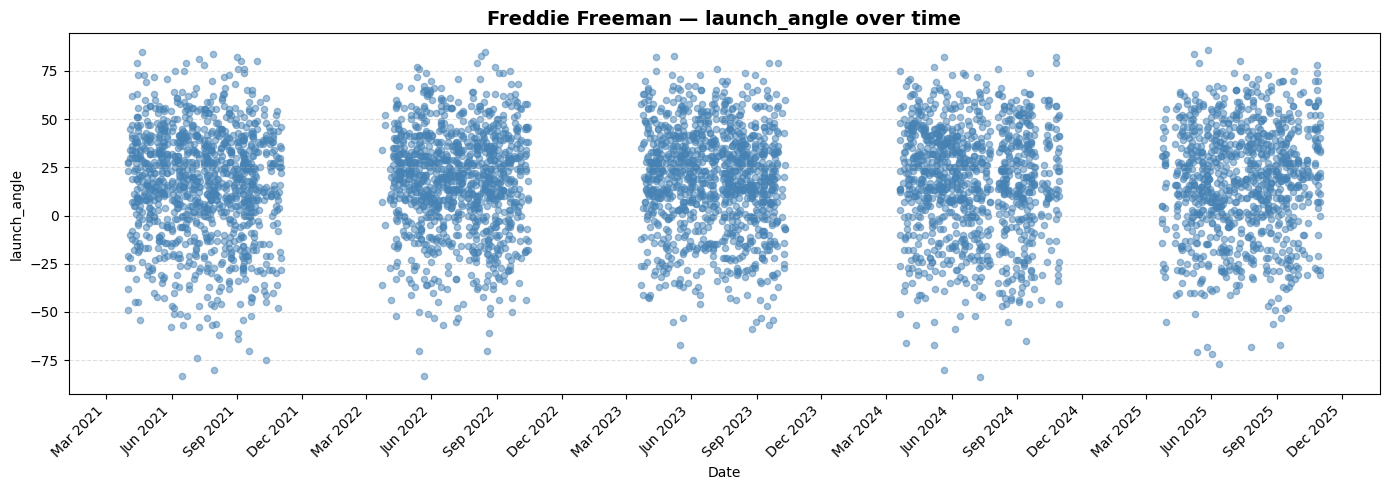

In [4]:
# Example usage
plot_player_time_series(df, player_name="Freddie Freeman", index="launch_angle")
# 4 indicadors

In [5]:
def cusum_changepoint(df, player_name, index, target=None, threshold=5.0):
    """
    Detect change points using CUSUM (Cumulative Sum Control Chart).

    Parameters
    ----------
    df        : pd.DataFrame  – full dataset
    player_name : str         – player name
    index     : str           – metric column to analyze
    target    : float         – target/baseline mean (if None, uses mean of data)
    threshold : float         – decision threshold for change point (default 5.0)

    Returns
    -------
    dict with keys:
        - 'cusum_pos': cumulative sum above target
        - 'cusum_neg': cumulative sum below target
        - 'changepoints': indices where significant deviations occur
        - 'dates': corresponding dates
        - 'values': metric values
        - 'dates_changepoint': dates of detected change points
    """
    player_df = df[df["Name"] == player_name].copy()
    
    if player_df.empty:
        raise ValueError(f"No data found for player: '{player_name}'")
    if index not in player_df.columns:
        raise ValueError(f"Column '{index}' not found in DataFrame.")
    
    player_df["game_date"] = pd.to_datetime(player_df["game_date"])
    player_df = player_df.sort_values("game_date").dropna(subset=[index])
    
    values = player_df[index].values
    dates = player_df["game_date"].values
    
    if target is None:
        target = np.mean(values)
    
    # Calculate standard deviation for scaling
    std_dev = np.std(values)
    if std_dev == 0:
        std_dev = 1
    
    # Normalize deviations
    normalized = (values - target) / std_dev
    
    # Calculate CUSUM
    cusum_pos = np.zeros_like(normalized)
    cusum_neg = np.zeros_like(normalized)
    
    for i in range(len(normalized)):
        cusum_pos[i] = max(0, cusum_pos[i-1] + normalized[i]) if i > 0 else max(0, normalized[i])
        cusum_neg[i] = min(0, cusum_neg[i-1] + normalized[i]) if i > 0 else min(0, normalized[i])
    
    # Detect change points
    changepoints = np.where((np.abs(cusum_pos) > threshold) | (np.abs(cusum_neg) > threshold))[0]
    
    return {
        'cusum_pos': cusum_pos,
        'cusum_neg': cusum_neg,
        'changepoints': changepoints,
        'dates': dates,
        'values': values,
        'dates_changepoint': dates[changepoints] if len(changepoints) > 0 else [],
        'target': target,
        'threshold': threshold
    }


def plot_cusum(cusum_result, player_name, index, figsize=(14, 6)):
    """
    Plot CUSUM chart with change points highlighted.

    Parameters
    ----------
    cusum_result : dict – output from cusum_changepoint()
    player_name  : str  – player name for title
    index        : str  – metric name for title
    figsize      : tuple – figure size
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    dates = cusum_result['dates']
    cusum_pos = cusum_result['cusum_pos']
    cusum_neg = cusum_result['cusum_neg']
    threshold = cusum_result['threshold']
    changepoints = cusum_result['changepoints']
    
    ax.plot(dates, cusum_pos, color='green', linewidth=2, label='CUSUM+')
    ax.plot(dates, cusum_neg, color='red', linewidth=2, label='CUSUM-')
    ax.axhline(y=threshold, color='gray', linestyle='--', alpha=0.6, label=f'Threshold (±{threshold})')
    ax.axhline(y=-threshold, color='gray', linestyle='--', alpha=0.6)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
    
    # Highlight change points
    if len(changepoints) > 0:
        ax.scatter(dates[changepoints], cusum_pos[changepoints], color='orange', s=100, 
                  marker='X', zorder=5, label='Change Points')
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=45, ha="right")
    
    ax.set_title(f"CUSUM Chart: {player_name} — {index}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("CUSUM Value")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Change points detected: {len(changepoints)}")
    if len(changepoints) > 0:
        print("Dates of change points:")
        for cp_date in cusum_result['dates_changepoint']:
            print(f"  {pd.Timestamp(cp_date).strftime('%Y-%m-%d')}")


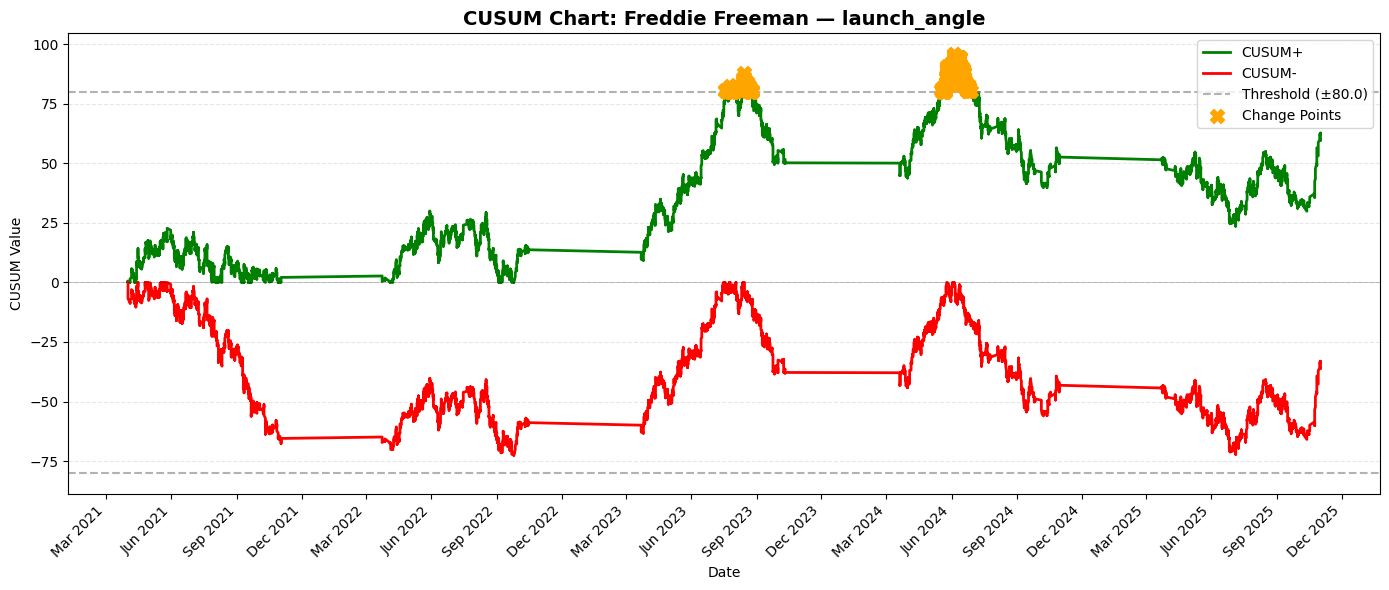

Change points detected: 324
Dates of change points:
  2023-07-19
  2023-07-19
  2023-07-22
  2023-07-25
  2023-07-25
  2023-07-25
  2023-07-25
  2023-07-25
  2023-07-25
  2023-07-25
  2023-07-25
  2023-07-25
  2023-07-26
  2023-07-26
  2023-07-26
  2023-07-26
  2023-07-26
  2023-07-26
  2023-07-26
  2023-07-28
  2023-07-29
  2023-07-29
  2023-07-29
  2023-07-29
  2023-07-29
  2023-07-30
  2023-07-30
  2023-07-30
  2023-07-30
  2023-07-30
  2023-08-01
  2023-08-01
  2023-08-01
  2023-08-01
  2023-08-02
  2023-08-02
  2023-08-02
  2023-08-02
  2023-08-03
  2023-08-03
  2023-08-03
  2023-08-03
  2023-08-03
  2023-08-11
  2023-08-11
  2023-08-11
  2023-08-12
  2023-08-12
  2023-08-12
  2023-08-12
  2023-08-12
  2023-08-12
  2023-08-12
  2023-08-13
  2023-08-13
  2023-08-13
  2023-08-13
  2023-08-13
  2023-08-13
  2023-08-15
  2023-08-15
  2023-08-15
  2023-08-15
  2023-08-15
  2023-08-15
  2023-08-16
  2023-08-16
  2023-08-16
  2023-08-16
  2023-08-16
  2023-08-16
  2023-08-16
  2023-08-16

In [9]:
# Example: CUSUM analysis
cusum_result = cusum_changepoint(df, player_name="Freddie Freeman", index="launch_angle", threshold=80.0)
plot_cusum(cusum_result, player_name="Freddie Freeman", index="launch_angle")


In [ ]:
# #### Build CPD 1 subdataset for the decision-based indicator using batter, pa_seq_id, and hitting_decisions_score.

# # X = pa_seq_id
# # Y = hitting_decisions_score

# SELECTED_PLAYER_ID = 660271  # e.g. Shohei Ohtani

# BASE_COLS = ["batter", "pa_uid", "game_date", "game_pk", "at_bat_number"]

# cpd_decision = (
#     df.loc[df["batter"] == SELECTED_PLAYER_ID, BASE_COLS + ["pa_seq_id", "hitting_decisions_score"]]
#       .dropna(subset=["pa_seq_id", "hitting_decisions_score"])
#       .sort_values("pa_seq_id")
#       .reset_index(drop=True)
# )


# #### Build CPD 2 subdataset for the power-efficiency indicator using batter, power_woba_seq_id, and power_efficiency.

# # X = power_woba_seq_id
# # Y = power_efficiency

# # Replace with the selected player ID (for example: 660271 = Shohei Ohtani)
# SELECTED_PLAYER_ID = 660271

# cpd_power_efficiency = (
#     df.loc[df["batter"] == SELECTED_PLAYER_ID,
#            ["batter", "pa_uid", "game_date", "game_pk", "at_bat_number",
#             "power_woba_seq_id", "power_efficiency"]]
#       .dropna(subset=["batter", "power_woba_seq_id", "power_efficiency"])
#       .sort_values(["batter", "power_woba_seq_id"])
#       .reset_index(drop=True)
# )

# #### Build CPD 3 subdataset for the wOBA-residual indicator using batter, power_woba_seq_id, and woba_residual.

# # X = power_woba_seq_id
# # Y = woba_residual

# # Replace with the selected player ID (for example: 660271 = Shohei Ohtani)
# SELECTED_PLAYER_ID = 660271

# cpd_woba_residual = (
#     df.loc[df["batter"] == SELECTED_PLAYER_ID,
#            ["batter", "pa_uid", "game_date", "game_pk", "at_bat_number",
#             "power_woba_seq_id", "woba_residual"]]
#       .dropna(subset=["batter", "power_woba_seq_id", "woba_residual"])
#       .sort_values(["batter", "power_woba_seq_id"])
#       .reset_index(drop=True)
# )

# cpd_woba_residual.head(15)

# #### Build CPD 4 subdataset for the launch-angle-stability indicator using batter, launch_angle_seq_id, and launch_angle_stability_50pa.

# # X = launch_angle_seq_id
# # Y = launch_angle_stability_50pa

# # Replace with the selected player ID (for example: 660271 = Shohei Ohtani)
# SELECTED_PLAYER_ID = 660271

# cpd_launch_angle_stability = (
#     df.loc[df["batter"] == SELECTED_PLAYER_ID,
#            ["batter", "pa_uid", "game_date", "game_pk", "at_bat_number",
#             "launch_angle_seq_id", "launch_angle_stability_50pa"]]
#       .dropna(subset=["batter", "launch_angle_seq_id", "launch_angle_stability_50pa"])
#       .sort_values(["batter", "launch_angle_seq_id"])
#       .reset_index(drop=True)
# )